# Multi-objective Bayesian Optimization for Variance Reduction

This notebook implements a multi-objective Bayesian optimization workflow for selecting bottom-up grown InP/InAsP microring laser designs. Growth and geometry parameters are used as input features, while the optimization considers three field-level objectives: reduced lasing-threshold variance, target emission wavelength, and low median lasing threshold.

## Reproducibility notes

The following input files are expected in the notebook working directory:

- `All_features_targets.pkl`: field-level input features and objective values from Batch 1 and Batch 2.
- `New_paramaters_reduced_var.csv`: saved candidate table used in the final formatting stage. This file can be regenerated by uncommenting the `to_csv` line in the MOBO output section.

The modelling workflow uses PyTorch, BoTorch, and GPyTorch for Gaussian-process-based Bayesian optimization. Matplotlib and seaborn are used for diagnostic visualizations.

In [ ]:
# ---------------------------------------------------------------------
# Notebook setup
# ---------------------------------------------------------------------
# Imports all numerical, plotting, PyTorch, GPytorch, BoTorch, and LHS
# dependencies used in the variance-aware Bayesian optimisation workflow.
# The tensor keyword dictionary (`tkwargs`) sets double precision and uses
# CUDA automatically when a GPU is available.

# basic dependencies
import numpy as np
from numpy import loadtxt, savetxt

import pandas as pd
import math
import time
from datetime import date
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

#########################################

# Statistical analysis
##PCA
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

#########################################

# torch dependencies
import torch

tkwargs = {"dtype": torch.double, # set as double to minimize zero error for cholesky decomposition error
           "device": torch.device("cuda:0" if torch.cuda.is_available() else "cpu")} # set tensors to GPU, if multiple GPUs please set cuda:x properly

torch.set_printoptions(precision=3)

###########################################


# botorch dependencies
import botorch

# data related
from botorch.utils.sampling import draw_sobol_samples
from botorch.utils.transforms import unnormalize, normalize

# surrogate model specific
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.model_list_gp_regression import ModelListGP
from botorch.models.transforms.outcome import Standardize
from botorch import fit_gpytorch_mll

# utilities
from botorch.optim.optimize import optimize_acqf,optimize_acqf_list
from botorch.sampling import SobolQMCNormalSampler
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.hypervolume import Hypervolume
from typing import Optional
from torch import Tensor
from botorch.exceptions import BadInitialCandidatesWarning
from botorch.utils.sampling import sample_simplex
from torch.optim import SGD
from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood
from botorch.acquisition.objective import GenericMCObjective
from botorch.utils.multi_objective.scalarization import get_chebyshev_scalarization
from botorch.acquisition.monte_carlo import qNoisyExpectedImprovement

#LHS
from pyDOE import lhs

#Warnings
import warnings
warnings.filterwarnings('ignore', category=BadInitialCandidatesWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

#####################################################################

# plotting dependencies
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

## Load the field-level dataset

The dataset is indexed by `sample_ID` and `field_ID`. Rows containing missing values are removed before model construction so that all objectives and design variables are available for every optimisation point.

In [ ]:
# ---------------------------------------------------------------------
# Load and clean the per-field optimisation dataset
# ---------------------------------------------------------------------
# Expected input file: All_features_targets.pkl
# Rows are indexed by sample_ID and field_ID, then incomplete rows are removed.

df = pd.read_pickle('All_features_targets.pkl')
df.set_index(['sample_ID', 'field_ID'], inplace=True)
df_clean = df.dropna()
df_clean

diameter  pitch  pitch-diam  nQWs  growth_Temp_QW  AsP_QW  \
sample_ID field_ID                                                              
127       1              4.0    7.5         3.5   8.0           600.0    0.92   
          2              6.0   10.0         4.0   8.0           600.0    0.92   
          3              8.0   12.0         4.0   8.0           600.0    0.92   
          4             10.0   13.0         3.0   8.0           600.0    0.92   
          5              5.0    7.5         2.5   8.0           600.0    0.92   
...                      ...    ...         ...   ...             ...     ...   
338       3              7.0   10.8         3.8   8.0           598.0    1.10   
          4              8.0   11.7         3.7   8.0           598.0    1.10   
          5              9.0   12.6         3.6   8.0           598.0    1.10   
          6             10.0   13.4         3.4   8.0           598.0    1.10   
          7             11.0   14.3         3.3   8.0           598.0    1.10   

                    InP_barrier  growth_time_cap  lasing_thresh_mean  \
sample_ID field_ID                                                     
127       1              1500.0            240.0          449.243282   
          2              1500.0            240.0          172.213490   
          3              1500.0            240.0          190.911014   
          4              1500.0            240.0          117.234767   
          5              1500.0            240.0          281.943313   
...                         ...              ...                 ...   
338       3              1715.0            243.0           71.286672   
          4              1715.0            243.0           88.143940   
          5              1715.0            243.0           84.484805   
          6              1715.0            243.0           70.729233   
          7              1715.0            243.0           62.581052   

                    lasing_thresh_variance     Yield  lasing_thresh_median  \
sample_ID field_ID                                                           
127       1                   44413.693652  0.691667            429.543520   
          2                    1686.721399  0.975000            165.291290   
          3                    2965.984280  0.982143            178.826444   
          4                     359.507390  1.000000            115.509624   
          5                   17308.345856  0.975000            230.302087   
...                                    ...       ...                   ...   
338       3                     481.545208  0.983333             67.109965   
          4                     532.017912  1.000000             84.981834   
          5                     338.680892  1.000000             80.190453   
          6                     187.040585  0.987500             70.048142   
          7                     196.162199  0.942857             59.343604   

                    lasing_wavelength_median  fractional_variance  
sample_ID field_ID                                                 
127       1                       975.402386             1.810238  
          2                      1108.835640             0.068748  
          3                      1126.766994             0.120889  
          4                      1145.089956             0.014653  
          5                      1087.967338             0.705463  
...                                      ...                  ...  
338       3                      1174.511302             0.145694  
          4                      1190.245207             0.160965  
          5                      1171.367442             0.102470  
          6                      1179.085931             0.056590  
          7                      1202.980213             0.059350  

[94 rows x 14 columns]

## Define design variables, objectives, and bounds

Seven input variables are used: two geometry parameters and five growth parameters. The three objectives are threshold variance, median lasing wavelength, and median lasing threshold. Since BoTorch maximises objectives by default, the two minimisation targets are sign-inverted.

In [24]:
# Define number of features and objectives
n_var = 7 # Number of X (Feature) values i.e. the number of growth parameters
n_obj = 3 # Number of y (objective) values i.e. Threshold, Wavelength and Yield
# define random state
random_state = 42 
torch.manual_seed(random_state) # gives a consistent seed based on the trial number

# Objectives df and tensor
obj_df = df_clean[['lasing_thresh_variance', 'lasing_wavelength_median', 'lasing_thresh_median']]
train_obj = torch.tensor(obj_df.values, **tkwargs)

train_obj[:, 0] = -train_obj[:, 0] #Botorch uses maximisation so negate it as we want to minimize threshold
train_obj[:, 2] = -train_obj[:, 2]

# Features df and tesnor
X_df=df_clean[['diameter', 'pitch-diam', 'nQWs', 'growth_Temp_QW', 'AsP_QW', 'InP_barrier', 'growth_time_cap']]
train_x = torch.tensor(X_df.values, **tkwargs)

# Define Problem bounds for each X values. These information is obtained through domain experts.
lower_bounds = torch.tensor([4, 2, 1, 590, 0.6, 1500, 60 ], **tkwargs) 
upper_bounds = torch.tensor([15, 15, 12, 620, 1.1, 4000, 240], **tkwargs)
problem_bounds = torch.vstack([lower_bounds, upper_bounds])

# Standard bounds i.e. 0 and 1 for normalization
standard_bounds = torch.zeros(2, n_var, **tkwargs)
standard_bounds[1] = 1

#Normalize
train_x_norm = normalize(train_x, problem_bounds)

print('Objective Tensor Shape:',train_obj.shape , '\nFeatures Tensor Shape:',train_x.shape)

Objective Tensor Shape: torch.Size([94, 3]) 
Features Tensor Shape: torch.Size([94, 7])


In [ ]:
# Quick inspection of the objective tensor after sign convention is applied.

train_obj

tensor([[-4.441e+04,  9.754e+02, -4.295e+02],
        [-1.687e+03,  1.109e+03, -1.653e+02],
        [-2.966e+03,  1.127e+03, -1.788e+02],
        [-3.595e+02,  1.145e+03, -1.155e+02],
        [-1.731e+04,  1.088e+03, -2.303e+02],
        [-8.484e+02,  1.119e+03, -1.666e+02],
        [-5.510e+02,  1.149e+03, -1.140e+02],
        [-1.884e+04,  1.048e+03, -3.313e+02],
        [-1.077e+04,  1.177e+03, -1.503e+02],
        [-1.428e+03,  9.539e+02, -2.088e+02],
        [-7.514e+03,  9.563e+02, -1.818e+02],
        [-1.167e+03,  9.610e+02, -1.956e+02],
        [-4.263e+03,  9.609e+02, -2.333e+02],
        [-1.079e+03,  9.543e+02, -1.477e+02],
        [-9.386e+02,  9.555e+02, -1.902e+02],
        [-2.631e+03,  9.552e+02, -2.123e+02],
        [-7.361e+03,  9.578e+02, -4.259e+02],
        [-8.671e+03,  9.532e+02, -3.777e+02],
        [-6.530e+03,  9.566e+02, -3.543e+02],
        [-1.170e+04,  9.687e+02, -3.292e+02],
        [-4.662e+03,  9.559e+02, -4.187e+02],
        [-6.051e+03,  9.549e+02, -

## Objective normalisation utilities

The following helper function applies min-max normalisation to DataFrame columns and optionally stores the bounds used for normalisation.

In [ ]:
# ---------------------------------------------------------------------
# Helper function: min-max normalisation for DataFrame columns
# ---------------------------------------------------------------------
# This function converts a pandas DataFrame to a torch tensor and normalises
# each column independently using its observed minimum and maximum.
# If bounds_save=True, the normalisation bounds are stored in the global
# variable `bounds_all` for later reuse.

# Define a function to normalize and convert it into tensor (Min-Max Scaling Normalization)
def normalize_df_tensor(df,  bounds_save=False):
    global bounds_all
    # Convert DataFrame to PyTorch tensor
    tensor_from_df = torch.tensor(df.values, **tkwargs)
    
    bounds_all = torch.empty(2,tensor_from_df.shape[1],**tkwargs)  # List to store bounds for each column
    # Normalize each column in the tensor
    for i in range(tensor_from_df.shape[1]):
        min_value = tensor_from_df[:, i].min()
        max_value = tensor_from_df[:, i].max()
        bounds = torch.vstack([min_value, max_value])    
        tensor_from_df[:, i] = normalize(tensor_from_df[:, i], bounds)
        if bounds_save==True:  # Save bounds if enabled
            bounds_all[0,i]= min_value
            bounds_all[1,i]= max_value
    return tensor_from_df

In [ ]:
# Normalise objective columns for a scale-independent diagnostic GP model.
# The sign convention is re-applied after normalisation for minimisation targets.

train_obj_norm=normalize_df_tensor(obj_df, bounds_save=True) #Normalize and convert into tensor

obj_bounds=bounds_all
train_obj_norm[:,0] = -train_obj_norm[:,0]
train_obj_norm[:,2] = -train_obj_norm[:,2]

print('Norm obj tensor:', train_obj_norm)

Norm obj tensor: tensor([[-1.000e+00,  7.728e-02, -8.661e-01],
        [-3.602e-02,  4.974e-01, -2.895e-01],
        [-6.488e-02,  5.539e-01, -3.191e-01],
        [-6.074e-03,  6.116e-01, -1.809e-01],
        [-3.885e-01,  4.317e-01, -4.314e-01],
        [-1.710e-02,  5.286e-01, -2.924e-01],
        [-1.039e-02,  6.229e-01, -1.776e-01],
        [-4.231e-01,  3.072e-01, -6.517e-01],
        [-2.410e-01,  7.109e-01, -2.567e-01],
        [-3.018e-02,  9.660e-03, -3.846e-01],
        [-1.675e-01,  1.727e-02, -3.255e-01],
        [-2.430e-02,  3.182e-02, -3.558e-01],
        [-9.415e-02,  3.159e-02, -4.380e-01],
        [-2.231e-02,  1.098e-02, -2.511e-01],
        [-1.914e-02,  1.457e-02, -3.439e-01],
        [-5.733e-02,  1.367e-02, -3.922e-01],
        [-1.640e-01,  2.196e-02, -8.581e-01],
        [-1.936e-01,  7.422e-03, -7.530e-01],
        [-1.453e-01,  1.797e-02, -7.019e-01],
        [-2.620e-01,  5.604e-02, -6.471e-01],
        [-1.031e-01,  1.594e-02, -8.424e-01],
        [-1.345e-

## Target correlation diagnostics

Before building the surrogate model, pairwise correlations between target variables were checked. This helps show whether the objectives carry overlapping or complementary information.

C:\Users\m89098ma\AppData\Local\Temp\ipykernel_14828\2707176157.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obj_df.dropna(inplace=True)


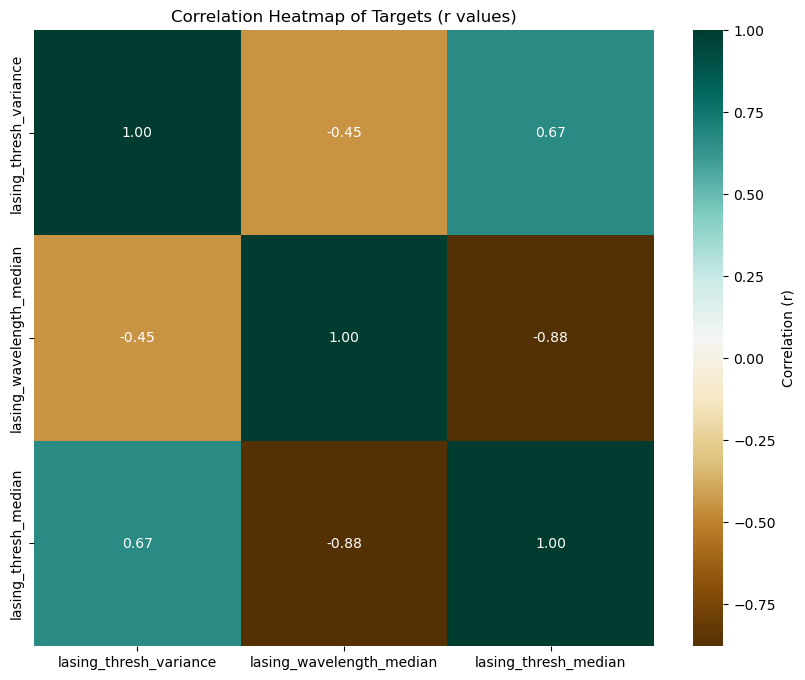

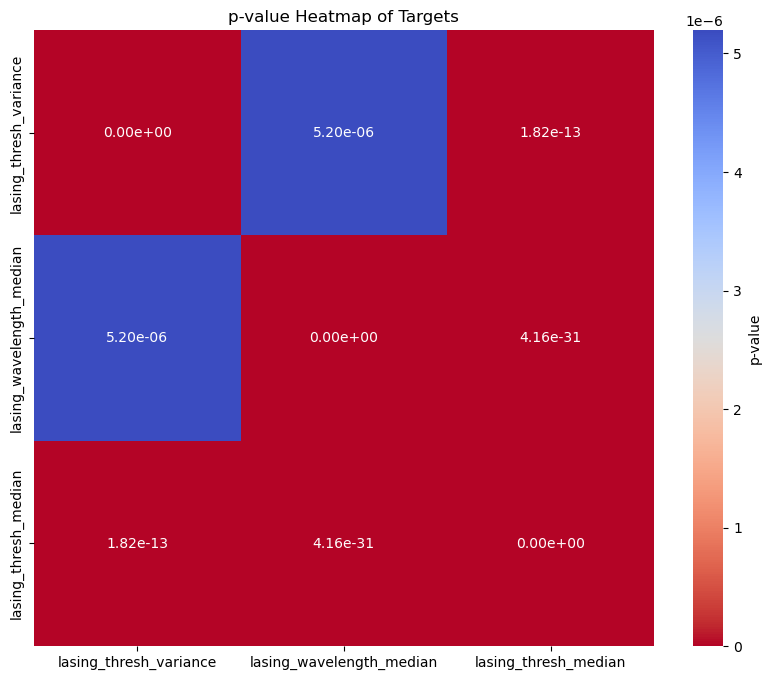

In [ ]:
# ---------------------------------------------------------------------
# Target correlation diagnostics
# ---------------------------------------------------------------------
# Pearson correlation coefficients and p-values are computed between the three
# target variables to check whether threshold variance, wavelength, and median
# threshold encode independent or related optimisation goals.
# Function to calculate correlation matrix with p-values
def corr_with_pvalues(df):
    cols = df.columns
    corr_matrix = np.zeros((len(cols), len(cols)))
    pval_matrix = np.zeros((len(cols), len(cols)))

    # Compute Pearson correlations and p-values
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                corr_matrix[i, j] = 1.0
                pval_matrix[i, j] = 0.0
            else:
                r, p = pearsonr(df[cols[i]], df[cols[j]])
                corr_matrix[i, j] = r
                pval_matrix[i, j] = p

    corr_df = pd.DataFrame(corr_matrix, columns=cols, index=cols)
    pval_df = pd.DataFrame(pval_matrix, columns=cols, index=cols)
    return corr_df, pval_df

obj_df.dropna(inplace=True)
# Calculate correlations and p-values
corr_matrix, pval_matrix = corr_with_pvalues(obj_df)

# Create a mask for upper triangle
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap of correlations (r values)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BrBG', fmt=".2f", cbar_kws={'label': 'Correlation (r)'})
plt.title("Correlation Heatmap of Targets (r values)")
plt.show()

# Plot heatmap of p-values
plt.figure(figsize=(10, 8))
sns.heatmap(pval_matrix, annot=True, cmap='coolwarm_r', fmt=".2e", cbar_kws={'label': 'p-value'})
plt.title("p-value Heatmap of Targets")
plt.show()


## Gaussian process surrogate model

This is the main multi-output surrogate model used for candidate generation. Each objective is modelled with a separate `SingleTaskGP`, and the models are combined using `ModelListGP`.

In [ ]:
# ---------------------------------------------------------------------
# Main GP surrogate model on physical target values
# --------------------------------------------------------------------

models = [] 
for i in range(train_obj.shape[-1]): # 3 seperate models for each objective
    train_y = train_obj[..., i : i + 1]
    models.append(SingleTaskGP(train_x_norm, train_y, outcome_transform=Standardize(m=1)))
model = ModelListGP(*models) #stack models
mll = SumMarginalLogLikelihood(model.likelihood, model)

fit_gpytorch_mll(mll) #fit model

C:\Users\m89098ma\Anaconda3\lib\site-packages\botorch\models\utils\assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)


SumMarginalLogLikelihood(
  (likelihood): LikelihoodList(
    (likelihoods): ModuleList(
      (0-2): 3 x GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): GammaPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
    )
  )
  (model): ModelListGP(
    (models): ModuleList(
      (0-2): 3 x SingleTaskGP(
        (likelihood): GaussianLikelihood(
          (noise_covar): HomoskedasticNoise(
            (noise_prior): GammaPrior()
            (raw_noise_constraint): GreaterThan(1.000E-04)
          )
        )
        (mean_module): ConstantMean()
        (covar_module): ScaleKernel(
          (base_kernel): MaternKernel(
            (lengthscale_prior): GammaPrior()
            (raw_lengthscale_constraint): Positive()
          )
          (outputscale_prior): GammaPrior()
          (raw_outputscale_constraint): Positive()
        )
        (outcome_transform): Standardize()
      )
    )
    (likelihood): LikelihoodList

In [ ]:
# Posterior predictions for the training data using the main GP model.
# These are used to evaluate in-sample fit and generate parity plots.

# Model Predictions
train_X=train_x_norm
train_Y=train_obj

with torch.no_grad():
    y_true = train_Y
    posterior = model.posterior(train_X)  
    y_pred = posterior.mean.squeeze()
    lower, upper = posterior.mvn.confidence_region() 
    yerr = upper-lower

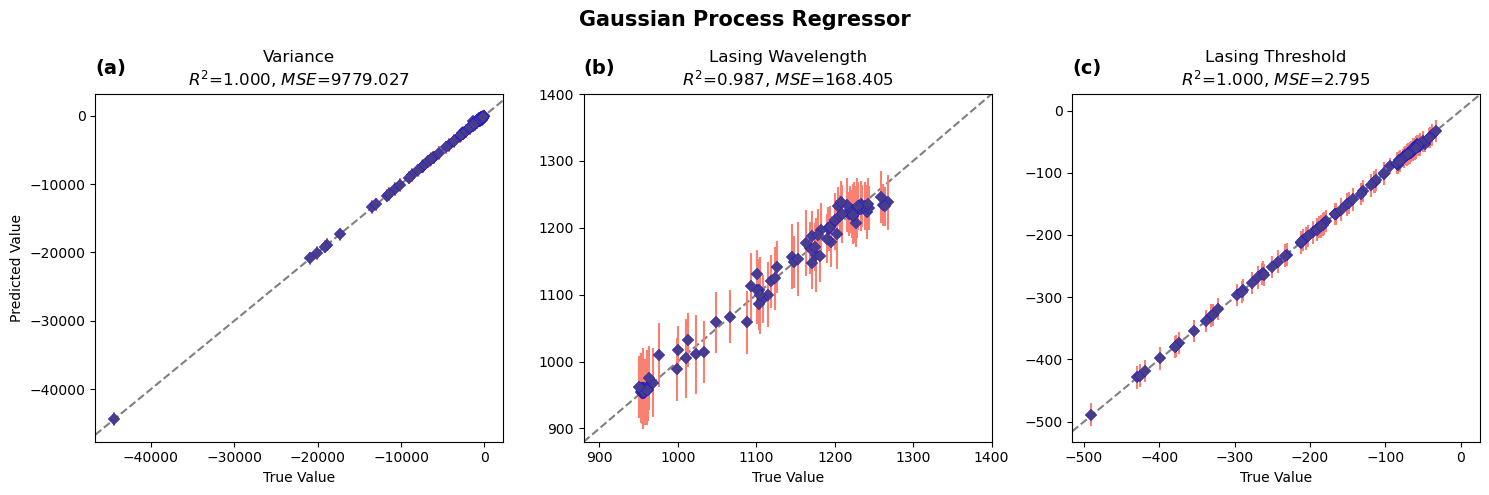

In [ ]:
# Evaluate GP fit using R² and MSE, then plot true-vs-predicted values.
# The wavelength panel is restricted to a physically relevant range.

# Check how well model fit the data
# Reordering the columns
#train_Y_reordered = train_Y[..., [2, 0, 1]]  # Reorder to [Yield, Threshold, Wavelength]
#y_pred_reordered = y_pred[..., [2, 0, 1]]
#yerr_reordered = yerr[..., [2, 0, 1]]

# Calculate R^2 and MSE for each objective
r2_vals = []
mse_vals = []

for i in range(3):
    #y_true_calc = train_Y_reordered[..., i].cpu().numpy()
    y_true_calc = train_Y[..., i].cpu().numpy()
    #y_pred_calc = y_pred_reordered[..., i].cpu().numpy()
    y_pred_calc = y_pred[..., i].cpu().numpy()
    mse = np.mean((y_true_calc - y_pred_calc) ** 2)
    r2 = 1 - (np.sum((y_true_calc - y_pred_calc) ** 2) / np.sum((y_true_calc - np.mean(y_true_calc)) ** 2))
    mse_vals.append(mse)
    r2_vals.append(r2)


# Plotting the graphs
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

for i, (obj, r2, mse) in enumerate(zip(["Variance", "Lasing Wavelength", "Lasing Threshold"], r2_vals, mse_vals)):
    
    ax[i].axline((1, 1), slope=1, color='gray', linestyle='--')
    
    ax[i].errorbar(x=train_Y[...,i].cpu().numpy(),
                   #x=train_Y_reordered[...,i].cpu().numpy(), 
                   y=y_pred[...,i].cpu().numpy(),
                   #y=y_pred_reordered[...,i].cpu().numpy(),
                   #yerr=yerr_reordered[...,i].cpu().numpy(),
                   yerr=yerr[...,i].cpu().numpy(),
                   ls='', marker='D', mec='b', mew=0.2, mfc='darkslateblue', c='salmon')
    
    ax[i].set_title(f"{obj}\n$R^2$={r2:.3f}, $MSE$={mse:.3f}")
    ax[i].set_xlabel('True Value')
    # Add subplot labels (a), (b), (c)
    ax[i].text(0, 1.1, f'({chr(97 + i)})', transform=ax[i].transAxes, 
               fontsize=14, fontweight='bold', va='top')

ax[0].set_ylabel('Predicted Value')

# Set Wavelength limit from 800 to 1400
#ax[2].set_xlim([880, 1650])
#ax[2].set_ylim([880, 1650])

#ax[0].set_xlim([-0.3, 1.4])
#ax[0].set_ylim([-0.3, 1.4])

ax[1].set_xlim([880, 1400])
ax[1].set_ylim([880, 1400])

fig.suptitle('Gaussian Process Regressor', fontsize=15, fontweight='bold')
fig.tight_layout()

plt.show()

## Candidate generation

A batch of candidate designs is generated using qNParEGO random scalarisations and noisy expected improvement. 

In [ ]:
# ---------------------------------------------------------------------
# Multi-objective Bayesian optimisation using qNParEGO
# ---------------------------------------------------------------------
# A list of scalarised qNEI acquisition functions is constructed with random
# simplex weights. Optimising these functions generates a batch of candidate
# growth and geometry recipes.


BATCH_SIZE = 50 # Define desired number of candidates 
MC_SAMPLES = 128
NUM_RESTARTS = 10
RAW_SAMPLES = 512

with torch.no_grad():
    pred = model.posterior(train_x_norm).mean #Get mean prediction

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES])) # Sample
#We are using qNParEGO    
acq_func_list = []
for _ in range(BATCH_SIZE):
    weights = sample_simplex(n_obj, **tkwargs).squeeze()
    objective = GenericMCObjective(get_chebyshev_scalarization(weights=weights, Y=pred)) #Scalarization for qNParEGO
    #Acquisition
    acq_func = qNoisyExpectedImprovement(
        model=model,
        objective=objective,
        X_baseline=train_x_norm,
        sampler=sampler,
        prune_baseline=True,
    )
    acq_func_list.append(acq_func)

# optimize and get a list of optimized candidates
candidates, _ = optimize_acqf_list(
    acq_function_list=acq_func_list,
    bounds=standard_bounds,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,  # used for intialization heuristic
    options={"batch_limit": 5, "maxiter": 200},
)

## Candidate inspection and objective prediction

The candidate designs are mapped back to physical parameter values and then evaluated using the trained surrogate model.

In [ ]:
# Convert optimised candidates from normalised design space back to the
# physical parameter ranges used for fabrication.

#unnormalize
new_x = unnormalize(candidates.detach(), bounds=problem_bounds)
#new_x

# We have 50 optimized candidates
df_candidates_50 = pd.DataFrame(new_x, columns=X_df.columns)
df_candidates_50

,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap
0,9.722199,2.532860,8.239365,594.532467,0.922762,1681.167093,223.911600
1,8.734538,4.095118,8.143840,591.832679,1.017562,1614.968524,235.218050
2,10.075472,2.000000,8.355035,595.022314,0.891436,1688.875133,218.354903
3,10.916069,3.172486,8.255721,593.106809,0.980253,1586.451954,231.774325
4,9.830656,3.553445,8.469583,595.461737,0.907729,1907.870401,227.682094
5,12.097025,2.000000,7.519406,596.805179,1.032573,2279.490246,201.701547
6,7.493086,2.000000,8.335629,591.134548,1.016010,1805.201217,240.000000
7,12.636461,4.650431,8.286222,591.060723,1.025546,1636.009697,240.000000
8,9.137136,6.071828,8.725213,591.351999,1.099838,1892.330859,239.948108
9,9.764473,2.000000,8.132516,593.697506,0.824855,1712.732574,226.052733


In [ ]:
# Predict objective values for each candidate recipe.
# Sign inversions are undone so the reported values are in the original
# physical interpretation: lower variance and lower threshold are better.

#Do predictions on each candidate
with torch.no_grad():
    posterior = model.posterior(candidates)  
    y_pred_cand = posterior.mean.squeeze()
    lower, upper = posterior.mvn.confidence_region()
    y_err_cand = upper-lower

y_pred_cand[:,0] = -y_pred_cand[:,0]
y_pred_cand[:,2] = -y_pred_cand[:,2]

#y_pred_unnorm_cand =  unnormalize(y_pred_cand, bounds=obj_bounds)
obj_cand_pred = y_pred_cand.cpu().numpy()

#y_err_unnorm_cand =  unnormalize(y_err_cand, bounds=obj_bounds)
obj_cand_err =  y_err_cand.cpu().numpy()

subset_col_pred = ['Predicted_Var', 'Predicted_Wavelength','Predicted_Thresh']
Optimized_df_pred = pd.DataFrame(obj_cand_pred, columns=subset_col_pred)
Optimized_df_pred

,Predicted_Var,Predicted_Wavelength,Predicted_Thresh
0,168.250376,1254.906426,31.830316
1,11.532772,1253.973976,62.630099
2,-190.473584,1244.372914,25.648230
3,601.950959,1260.408491,73.070055
4,212.423401,1239.768221,48.667752
5,3971.235105,1141.721333,170.683931
6,-1779.685034,1228.923739,69.529522
7,2962.282082,1228.037185,125.275717
8,1336.271965,1243.490732,84.536836
9,-164.257749,1233.149204,42.236183


In [ ]:
# Identify candidates that perform well for each target:
#   - lowest predicted median threshold
#   - lowest predicted threshold variance
#   - highest predicted wavelength

# Find indices of lowest two values in first column
lowest_indices_thresh = Optimized_df_pred['Predicted_Thresh'].nsmallest(3).index
lowest_indices_var = Optimized_df_pred['Predicted_Var'].abs().nsmallest(3).index

# Find indices of highest two values from second and third column
highest_indices_wavelength = Optimized_df_pred['Predicted_Wavelength'].nlargest(3).index

# Get corresponding values
lowest_values_thresh = Optimized_df_pred['Predicted_Thresh'].iloc[lowest_indices_thresh]
lowest_values_var = Optimized_df_pred['Predicted_Var'].iloc[lowest_indices_var]
highest_values_wavelength = Optimized_df_pred['Predicted_Wavelength'].iloc[highest_indices_wavelength]

print("Indices of lowest two values in Predicted Threshold:", lowest_indices_thresh.values)
print("Corresponding values:", lowest_values_thresh.values)
print("Indices of highest two values in Predicted Wavelength:", highest_indices_wavelength.values)
print("Corresponding values:", highest_values_wavelength.values)
print("Indices of lowest two values in Predicted Variance:", lowest_indices_var.values)
print("Corresponding values:", lowest_values_var.values)

Indices of lowest two values in Predicted Threshold: [ 2  0 26]
Corresponding values: [25.648 31.830 32.973]
Indices of highest two values in Predicted Wavelength: [ 3  0 47]
Corresponding values: [1260.408 1254.906 1254.603]
Indices of lowest two values in Predicted Variance: [28  1 15]
Corresponding values: [9.485 11.533 19.030]


## Final candidate selection

A subset of candidate recipes is manually selected for the next design stage. The original selected indices are retained.

In [ ]:
# Manually select the final candidate recipes for downstream fabrication design.
# The selected indices are preserved from the original workflow.

# Chosen Candidates
indices = [0, 1, 2, 28]

# Select rows based on given indices
df_final_candidates = df_candidates_50.iloc[indices]

df_final_candidates # Chosen final four candidates

,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap
0,9.722199,2.532860,8.239365,594.532467,0.922762,1681.167093,223.911600
1,8.734538,4.095118,8.143840,591.832679,1.017562,1614.968524,235.218050
2,10.075472,2.000000,8.355035,595.022314,0.891436,1688.875133,218.354903
28,9.871623,2.843487,8.415601,595.925179,0.917092,1751.508098,224.532189


## Convert candidates to fabrication-compatible values

The selected continuous parameters are rounded or converted into practically usable values for subsequent experimental design.

In [ ]:
# ---------------------------------------------------------------------
# Fabrication-compatible rounding
# ---------------------------------------------------------------------
# Converts selected continuous candidate values into practical recipe values.
# Note: this function modifies the provided DataFrame in place; this behaviour
# is preserved to keep the original workflow unchanged.

# Process dataframe function to convert features into required significant digits
def process_dataframe(df):
    """
    Process the DataFrame according to specified operations:
    1. Round and convert the first two columns to integers.
    2. Round and convert the fourth column to integers.
    3. Round the 'pitch-diam' and 'growt_AsP_qw' columns to two significant digits.
    4. Round and convert the last two columns to integers.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to process.

    Returns:
    pd.DataFrame: The processed DataFrame.
    """

    # Convert 'pitch-diam' to two significant digits
    df['pitch-diam'] = df['pitch-diam'].apply(
        lambda x: np.round(x, 1 - int(np.floor(np.log10(abs(x))))) if x != 0 else 0)
    
    # Round and convert the first two columns to integers
    df.iloc[:, 0] = df.iloc[:, 0].round().astype(int)

    df.iloc[:, 2] = df.iloc[:, 2].round().astype(int)
    
    # Round and convert the fourth column to integers
    df.iloc[:, 3] = df.iloc[:, 3].round().astype(int)
    
    
    # Convert 'growt_AsP_qw' to two significant digits
    df['AsP_QW'] = df['AsP_QW'].apply(
        lambda x: np.round(x, 1 - int(np.floor(np.log10(abs(x))))) if x != 0 else 0
    )
    
    # Round and convert the last two columns to integers
    df.iloc[:, -2:] = df.iloc[:, -2:].round().astype(int)
    
    return df

# Example usage
# df_final_candidates = pd.DataFrame({
#     'col1': [1.1, 2.5, 3.7],
#     'col2': [4.6, 5.1, 6.3],
#     'col3': [7.8, 8.9, 9.0],
#     'col4': [10.1, 11.2, 12.3],
#     'pitch-diam': [0.1234, 5.6789, 0.00012],
#     'growt_AsP_qw': [0.4567, 8.9123, 0.00034],
#     'col5': [13.4, 14.5, 15.6],
#     'col6': [16.7, 17.8, 18.9]
# })

#df_final_candidates = process_dataframe(df_final_candidates)
#print(df_final_candidates)

In [ ]:
# Apply fabrication-compatible rounding to the selected candidate recipes.

df_final_candidates_int = process_dataframe(df_final_candidates)
df_final_candidates_int

C:\Users\m89098ma\AppData\Local\Temp\ipykernel_14828\793630340.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pitch-diam'] = df['pitch-diam'].apply(
C:\Users\m89098ma\AppData\Local\Temp\ipykernel_14828\793630340.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AsP_QW'] = df['AsP_QW'].apply(


,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap
0,10.0,2.5,8.0,595.0,0.92,1681.0,224.0
1,9.0,4.1,8.0,592.0,1.00,1615.0,235.0
2,10.0,2.0,8.0,595.0,0.89,1689.0,218.0
28,10.0,2.8,8.0,596.0,0.92,1752.0,225.0


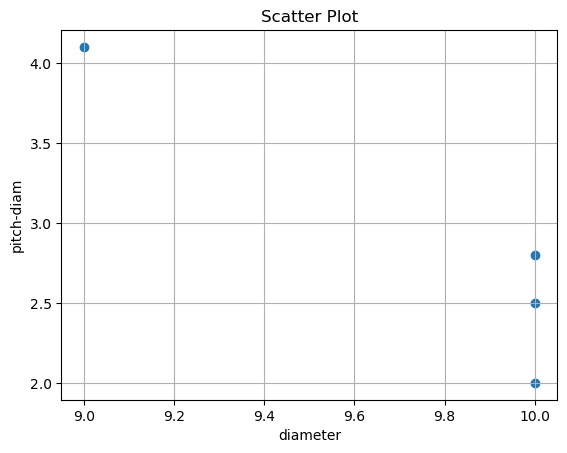

In [ ]:
# Visualise the selected design points in diameter vs pitch-diameter space.

#Scatter plot of 'diameter' and 'pitch-diameter'
plt.scatter(df_final_candidates['diameter'], df_final_candidates['pitch-diam'])
plt.xlabel('diameter')
plt.ylabel('pitch-diam')
plt.title('Scatter Plot')
plt.grid(True)
plt.show()

## Expand geometry parameter combinations with LHS

Latin Hypercube Sampling is used within the selected geometry range to add additional diameter and pitch-diameter combinations while keeping the chosen growth recipes fixed.

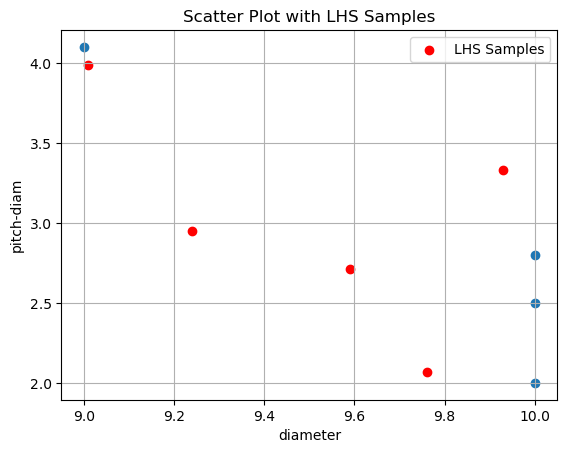

In [ ]:

# LHS points are generated within the selected candidate geometry envelope to check the effects of geometry parameter combinations while keeping the growth recipes fixed.

#LHS within the range
# Define the range for sampling 
min_diameter = min(df_final_candidates['diameter'])
max_diameter = max(df_final_candidates['diameter'])
min_pitch_diam = min(df_final_candidates['pitch-diam'])
max_pitch_diam = max(df_final_candidates['pitch-diam'])

# Number of samples to generate
num_samples = 5

# Generate Latin Hypercube Samples
lhs_samples = lhs(2, samples=num_samples, criterion="maximin")

# Scale the samples to the range of the original data and round to two decimal places
lhs_samples[:, 0] = np.around(lhs_samples[:, 0] * (max_diameter - min_diameter) + min_diameter, 2)
lhs_samples[:, 1] = np.around(lhs_samples[:, 1] * (max_pitch_diam - min_pitch_diam) + min_pitch_diam, 2)

# Plot the LHS samples
plt.scatter(df_final_candidates['diameter'], df_final_candidates['pitch-diam'])
plt.scatter(lhs_samples[:, 0], lhs_samples[:, 1], color='red', label='LHS Samples')
plt.xlabel('diameter')
plt.ylabel('pitch-diam')
plt.title('Scatter Plot with LHS Samples')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Inspect the generated LHS geometry samples.

lhs_samples

array([[9.240, 2.950],
       [9.760, 2.070],
       [9.010, 3.990],
       [9.590, 2.710],
       [9.930, 3.330]])

In [ ]:
# Combine selected candidate geometries with the LHS-generated geometries.

# Geometry Parameters
new_values_df = pd.DataFrame(lhs_samples, columns=['diameter', 'pitch-diam'])
diam_pitch_df = pd.concat([df_final_candidates[['diameter', 'pitch-diam']], new_values_df], ignore_index=True)  
diam_pitch_df ['diameter'] = diam_pitch_df ['diameter'].round()
diam_pitch_df

,diameter,pitch-diam
0,10.0,2.50
1,9.0,4.10
2,10.0,2.00
3,10.0,2.80
4,9.0,2.95
5,10.0,2.07
6,9.0,3.99
7,10.0,2.71
8,10.0,3.33


In [ ]:
# Replicate the geometry set for each selected growth recipe / wafer group.

# Concatenate the DataFrame with itself four times (Four Samples/Four sets of Growth Parameters)
diam_pitch_all_df = pd.concat([diam_pitch_df] * 4, ignore_index=True)
diam_pitch_all_df

,diameter,pitch-diam
0,10.0,2.50
1,9.0,4.10
2,10.0,2.00
3,10.0,2.80
4,9.0,2.95
5,10.0,2.07
6,9.0,3.99
7,10.0,2.71
8,10.0,3.33
9,10.0,2.50


In [ ]:
# Replicate the growth recipe parameters so they align with all geometry points.

# Replicate nine times (Nine sets of Geometry parameters)
subset_cols = ['nQWs', 'growth_Temp_QW', 'AsP_QW', 'InP_barrier', 'growth_time_cap']
df_wafer = df_final_candidates[subset_cols].copy()

# Select subset columns and replicate the DataFrame nine times
df_wafer = df_wafer.loc[df_wafer.index.repeat(9)].reset_index(drop=True)

df_wafer

,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap
0,8.0,595.0,0.92,1681.0,224.0
1,8.0,595.0,0.92,1681.0,224.0
2,8.0,595.0,0.92,1681.0,224.0
3,8.0,595.0,0.92,1681.0,224.0
4,8.0,595.0,0.92,1681.0,224.0
5,8.0,595.0,0.92,1681.0,224.0
6,8.0,595.0,0.92,1681.0,224.0
7,8.0,595.0,0.92,1681.0,224.0
8,8.0,595.0,0.92,1681.0,224.0
9,8.0,592.0,1.00,1615.0,235.0


## Construct the final growth–geometry design space

The geometry combinations and growth recipes are aligned into one table, then passed back through the trained surrogate model for predicted objective values.

In [ ]:
# Merge geometry and growth parameters into the final candidate design matrix.

# Joining the two DataFrames vertically- Growth and Geometry Parameters-final Set 
df_param_final = pd.concat([diam_pitch_all_df, df_wafer], axis=1)
df_param_final

,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap
0,10.0,2.50,8.0,595.0,0.92,1681.0,224.0
1,9.0,4.10,8.0,595.0,0.92,1681.0,224.0
2,10.0,2.00,8.0,595.0,0.92,1681.0,224.0
3,10.0,2.80,8.0,595.0,0.92,1681.0,224.0
4,9.0,2.95,8.0,595.0,0.92,1681.0,224.0
5,10.0,2.07,8.0,595.0,0.92,1681.0,224.0
6,9.0,3.99,8.0,595.0,0.92,1681.0,224.0
7,10.0,2.71,8.0,595.0,0.92,1681.0,224.0
8,10.0,3.33,8.0,595.0,0.92,1681.0,224.0
9,10.0,2.50,8.0,592.0,1.00,1615.0,235.0


In [ ]:
# Predict objective values for all final geometry-growth combinations.

#Do Predictions
# Convert pandas DataFrame to torch tensor
tensor_par = torch.tensor(df_param_final.values)
par_norm = normalize(tensor_par, problem_bounds)

with torch.no_grad():
    posterior = model.posterior(par_norm)  
    y_pred_all = posterior.mean.squeeze()
    lower, upper = posterior.mvn.confidence_region()
    y_err_all = upper-lower

y_pred_all[:,0] = -y_pred_all[:,0]

#y_pred_unnorm_cand =  unnormalize(y_pred_cand, bounds=obj_bounds)
obj_pred = y_pred_all.cpu().numpy()

#y_err_unnorm_cand =  unnormalize(y_err_cand, bounds=obj_bounds)
obj_err =   y_err_all.cpu().numpy()

subset_col_pred = ['Predicted_Var', 'Predicted_Wavelength','Predicted_Thresh']
Optimized_df_all_pred = pd.DataFrame(obj_pred, columns=subset_col_pred)
Optimized_df_all_pred

,Predicted_Var,Predicted_Wavelength,Predicted_Thresh
0,131.724224,1250.421274,-30.173022
1,374.862306,1235.571771,-45.760437
2,49.909509,1248.439870,-28.147798
3,179.643487,1250.777327,-31.665903
4,284.594797,1238.352414,-41.011225
5,61.410453,1248.820612,-28.388362
6,366.860990,1235.978113,-45.472558
7,165.422501,1250.735585,-31.201492
8,259.377464,1249.964019,-34.571654
9,472.344037,1256.006552,-64.590057


In [ ]:
# Combine final design parameters and GP predictions into a single table.

# Joining the two DataFrames vertically
MOBO_df = pd.concat([df_param_final, Optimized_df_all_pred], axis=1)

## Format and save the MOBO candidate table

The final MOBO output is sorted and labelled by wafer group to make the table easier to inspect and share.

In [ ]:
# ---------------------------------------------------------------------
# Format final table by wafer group
# ---------------------------------------------------------------------
# Rows are sorted by diameter within each InP barrier group, and wafer labels
# are inserted at the first row of each group for readability.

# Function to merge rows within each group
def merge_rows(group, group_name):
    # Sort the group by column 'B'
    group_sorted = group.sort_values(by='diameter').reset_index(drop=True)
    
    # Initialize the Group column with empty strings
    group_sorted['Wafer'] = ''
    
    # Set the Group column for the first row of each group
    group_sorted.at[0, 'Wafer'] = group_name
    
    return group_sorted

# Initialize a counter for group names
wafer_counter = ord('L')

# Function to apply to each group
def apply_merge_rows(group):
    global wafer_counter
    group_name = f"Wafer {chr(wafer_counter)}"
    result = merge_rows(group, group_name)
    wafer_counter += 1
    return result

# Apply the merge_rows function to each group
df_grouped_sorted = MOBO_df.groupby('InP_barrier', group_keys=False).apply(apply_merge_rows).reset_index(drop=True)

# Reorder columns to place 'Group' first
cols = ['Wafer'] + [col for col in df_grouped_sorted.columns if col != 'Wafer']
df_grouped_sorted = df_grouped_sorted[cols]
df_grouped_sorted

C:\Users\m89098ma\AppData\Local\Temp\ipykernel_14828\1623219868.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped_sorted = MOBO_df.groupby('InP_barrier', group_keys=False).apply(apply_merge_rows).reset_index(drop=True)


,Wafer,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap,Predicted_Var,Predicted_Wavelength,Predicted_Thresh
0,Wafer L,9.0,4.10,8.0,592.0,1.00,1615.0,235.0,121.191558,1255.603801,-59.411303
1,,9.0,2.95,8.0,592.0,1.00,1615.0,235.0,-142.400719,1253.641948,-59.358208
2,,9.0,3.99,8.0,592.0,1.00,1615.0,235.0,95.831325,1255.568159,-59.376846
3,,10.0,2.50,8.0,592.0,1.00,1615.0,235.0,472.344037,1256.006552,-64.590057
4,,10.0,2.00,8.0,592.0,1.00,1615.0,235.0,375.972206,1252.872655,-64.111427
5,,10.0,2.80,8.0,592.0,1.00,1615.0,235.0,529.271246,1257.341082,-64.967939
6,,10.0,2.07,8.0,592.0,1.00,1615.0,235.0,389.500248,1253.380935,-64.164298
7,,10.0,2.71,8.0,592.0,1.00,1615.0,235.0,512.310358,1256.982571,-64.849040
8,,10.0,3.33,8.0,592.0,1.00,1615.0,235.0,626.177989,1258.767601,-65.736278
9,Wafer M,9.0,4.10,8.0,595.0,0.92,1681.0,224.0,374.862306,1235.571771,-45.760437


In [ ]:
# Summarise the final MOBO design table.
# To regenerate the CSV used in the next section, uncomment the to_csv line.

#Save MOBO Dataset
#df_grouped_sorted.to_csv('New_paramaters_reduced_var.csv', index=False)
df_grouped_sorted.describe()

,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap,Predicted_Var,Predicted_Wavelength,Predicted_Thresh
count,36.000000,36.000000,36.0,36.000000,36.00000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,9.666667,2.938889,8.0,594.500000,0.93250,1684.250000,225.500000,236.446834,1242.704675,-42.317575
std,0.478091,0.717686,0.0,1.521278,0.04143,49.213456,6.189853,284.987394,10.602346,14.143496
min,9.000000,2.000000,8.0,592.000000,0.89000,1615.000000,218.000000,-142.400719,1223.784599,-65.736278
25%,9.000000,2.500000,8.0,594.250000,0.91250,1664.500000,222.500000,41.725433,1237.445683,-52.357850
50%,10.000000,2.800000,8.0,595.000000,0.92000,1685.000000,224.500000,150.458162,1241.007695,-38.585197
75%,10.000000,3.330000,8.0,595.250000,0.94000,1704.750000,227.500000,375.139781,1251.301159,-30.677419
max,10.000000,4.100000,8.0,596.000000,1.00000,1752.000000,235.000000,938.719057,1258.767601,-23.491910


In [ ]:
# ---------------------------------------------------------------------
# Prepare compact fabrication/output table
# ---------------------------------------------------------------------
# This cell reloads the saved MOBO table.
# Ensure `New_paramaters_reduced_var.csv` exists in the working directory,
# or uncomment the save line in the previous section before running this cell.

opt_var_par = pd.read_csv('New_paramaters_reduced_var.csv')
opt_var_par

,Wafer,diameter,pitch-diam,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap,Predicted_Var,Predicted_Wavelength,Predicted_Thresh
0,Wafer L,9.0,4.10,8.0,592.0,1.00,1615.0,235.0,121.191558,1255.603801,-59.411303
1,NaN,9.0,2.95,8.0,592.0,1.00,1615.0,235.0,-142.400719,1253.641948,-59.358208
2,NaN,9.0,3.99,8.0,592.0,1.00,1615.0,235.0,95.831325,1255.568159,-59.376846
3,NaN,10.0,2.50,8.0,592.0,1.00,1615.0,235.0,472.344037,1256.006552,-64.590057
4,NaN,10.0,2.00,8.0,592.0,1.00,1615.0,235.0,375.972206,1252.872655,-64.111427
5,NaN,10.0,2.80,8.0,592.0,1.00,1615.0,235.0,529.271246,1257.341082,-64.967939
6,NaN,10.0,2.07,8.0,592.0,1.00,1615.0,235.0,389.500248,1253.380935,-64.164298
7,NaN,10.0,2.71,8.0,592.0,1.00,1615.0,235.0,512.310358,1256.982571,-64.849040
8,NaN,10.0,3.33,8.0,592.0,1.00,1615.0,235.0,626.177989,1258.767601,-65.736278
9,Wafer M,9.0,4.10,8.0,595.0,0.92,1681.0,224.0,374.862306,1235.571771,-45.760437


In [ ]:
# Convert pitch-diameter representation into absolute pitch for fabrication.

# Add the 'pitch' column (sum of 'diameter' and 'pitch-diam')
opt_var_par['pitch'] = opt_var_par['diameter'] + opt_var_par['pitch-diam']

# Reorder columns to have 'pitch' next to 'pitch-diam'
cols = opt_var_par.columns.tolist()
cols.insert(cols.index('pitch-diam') + 1, cols.pop(cols.index('pitch')))
opt_var_par = opt_var_par[cols]
opt_var_par

,Wafer,diameter,pitch-diam,pitch,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap,Predicted_Var,Predicted_Wavelength,Predicted_Thresh
0,Wafer L,9.0,4.10,13.10,8.0,592.0,1.00,1615.0,235.0,121.191558,1255.603801,-59.411303
1,NaN,9.0,2.95,11.95,8.0,592.0,1.00,1615.0,235.0,-142.400719,1253.641948,-59.358208
2,NaN,9.0,3.99,12.99,8.0,592.0,1.00,1615.0,235.0,95.831325,1255.568159,-59.376846
3,NaN,10.0,2.50,12.50,8.0,592.0,1.00,1615.0,235.0,472.344037,1256.006552,-64.590057
4,NaN,10.0,2.00,12.00,8.0,592.0,1.00,1615.0,235.0,375.972206,1252.872655,-64.111427
5,NaN,10.0,2.80,12.80,8.0,592.0,1.00,1615.0,235.0,529.271246,1257.341082,-64.967939
6,NaN,10.0,2.07,12.07,8.0,592.0,1.00,1615.0,235.0,389.500248,1253.380935,-64.164298
7,NaN,10.0,2.71,12.71,8.0,592.0,1.00,1615.0,235.0,512.310358,1256.982571,-64.849040
8,NaN,10.0,3.33,13.33,8.0,592.0,1.00,1615.0,235.0,626.177989,1258.767601,-65.736278
9,Wafer M,9.0,4.10,13.10,8.0,595.0,0.92,1681.0,224.0,374.862306,1235.571771,-45.760437


In [ ]:
# Remove prediction-only columns and use Wafer as the table index.

# Remove the 'pitch-diam' column
opt_var_par = opt_var_par.drop(columns=['pitch-diam','Predicted_Var', 'Predicted_Wavelength', 'Predicted_Thresh'])
# Set 'Wafer' column as the index
opt_var_par = opt_var_par.set_index('Wafer')
opt_var_par

,diameter,pitch,nQWs,growth_Temp_QW,AsP_QW,InP_barrier,growth_time_cap
Wafer,,,,,,,
Wafer L,9.0,13.10,8.0,592.0,1.00,1615.0,235.0
NaN,9.0,11.95,8.0,592.0,1.00,1615.0,235.0
NaN,9.0,12.99,8.0,592.0,1.00,1615.0,235.0
NaN,10.0,12.50,8.0,592.0,1.00,1615.0,235.0
NaN,10.0,12.00,8.0,592.0,1.00,1615.0,235.0
NaN,10.0,12.80,8.0,592.0,1.00,1615.0,235.0
NaN,10.0,12.07,8.0,592.0,1.00,1615.0,235.0
NaN,10.0,12.71,8.0,592.0,1.00,1615.0,235.0
NaN,10.0,13.33,8.0,592.0,1.00,1615.0,235.0


In [ ]:
# Save the final compact parameter table for sharing/fabrication.

opt_var_par.to_csv('New_parameters_to_send_first_predictions_var.csv',index=False)